# Amazon fine foods reviews

## Group 3: Saeka Ono, Silvia López Roldán, Ronald Núñez, William Yammine

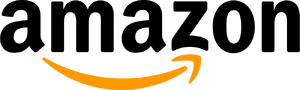

## **1. Business context and project objective**

In many large online platforms, valuable user and product remain underused. In our scenario, the company currently relies on a randomized product display strategy, which ignores patterns in customer behavior, product popularity and reviews. As a result, users may be shown items that are irrelevant to their interests, while the business misses opportunities to increase engagement and satisfaction.

This notebook develops a recommendation system proof of concept designed to  provide more informed and personalized suggestions. We explore several recommender families, including non-personalized baselines, collaborative filtering, content-based recommendation, and hybrid methods. We evaluate them not only from a predictive perspective, but also from a ranking and business-value perspective, in order to identify which approach offers the strongest practical benefit.

####################

This notebook aims to:

1. Understand the structure, strengths, and limitations of the available dataset.
2. Build a sequence of recommender systems of increasing sophistication.
3. Compare recommendation approaches using appropriate evaluation methods.
4. Estimate the added value of recommendation over randomized product display.
5. Present the results in a way that is accessible to both technical and non-technical stakeholders.

###########################

## **2. Dataset Overview**

### 2.1 Imports

In [1]:
%%capture

# 1. Change the Python version in Colab [Runtime > Change runtime type > Version to "2025.07"]
# This will move from Python 3.12 (incompatible) to Python 3.11 (compatible)
!pip install matplotlib==3.7.3, numpy==1.26.4, pandas==1.5.3, seaborn==0.11.2

# 2. Once the lower versions are installed, it is necessary to restart the session [Runtime > Restart session]

In [1]:
! python --version

Python 3.11.13


In [2]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2402446 sha256=2ea9488c8930e34e53f8c70af04fc5dfed59d4f7b705a6465464869b0c3a48ca
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [3]:
!pip install -q kaggle

In [4]:
import warnings
warnings.filterwarnings("ignore")

import gc
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader, NormalPredictor, KNNBasic, KNNWithMeans, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import BaselineOnly

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2.2 Data source

In [5]:
import os
import zipfile

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Download our dataset from kaggle

In [6]:
!kaggle datasets download -d arhamrumi/amazon-product-reviews

Dataset URL: https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews
License(s): CC0-1.0
  0% 0.00/115M [00:00<?, ?B/s]
100% 115M/115M [00:00<00:00, 1.40GB/s]


In [7]:
!unzip -o amazon-product-reviews.zip

Archive:  amazon-product-reviews.zip
  inflating: Reviews.csv             


### 2.3 Dataset structure


In [8]:
!ls

amazon-product-reviews.zip  kaggle.json  Reviews.csv  sample_data


In [9]:
df = pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


In [10]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Data types:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               16
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [11]:
n_reviews = len(df)
n_users = df["UserId"].nunique()
n_products = df["ProductId"].nunique()

print(f"Number of reviews: {n_reviews:,}")
print(f"Number of unique users: {n_users:,}")
print(f"Number of unique products: {n_products:,}")

sparsity = 1 - (n_reviews / (n_users * n_products))
print(f"Approximate user-item sparsity: {sparsity:.6f}")

Number of reviews: 568,454
Number of unique users: 256,059
Number of unique products: 74,258
Approximate user-item sparsity: 0.999970


Before building any recommender system, we need to understand how users interact with products and how reliable the available signals are.

In this dataset, each row represents a review left by a user for a product, along with a numerical score and a piece of review text. This makes the data suitable for several recommendation paradigms:

- **Collaborative filtering**, because we have user IDs, product IDs, and explicit ratings.
- **Content-based recommendation**, because we also have textual information in the review summary and full review text.
- **Hybrid approaches**, because both interaction and text signals are available.

In this section, we prepare the data for later modeling and study a few key behavioral patterns. The goal is not to create as many plots as possible, but to extract the patterns that matter most for recommendation design and evaluation.

#########################

## **3. Data Preparation and Feature Engineering**

In [12]:
df = df.copy()

# Fill small missing text fields
df["ProfileName"] = df["ProfileName"].fillna("Unknown")
df["Summary"] = df["Summary"].fillna("")

# Combine summary and review text for later content-based methods
df["full_text"] = (df["Summary"] + " " + df["Text"]).str.strip()

# Convert timestamp into datetime
df["review_time"] = pd.to_datetime(df["Time"], unit="s")

# Helpfulness ratio
df["helpfulness_ratio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"],
    0
)

# Review length features
df["text_length_chars"] = df["Text"].astype(str).apply(len)
df["text_length_words"] = df["Text"].astype(str).apply(lambda x: len(x.split()))

print("Prepared dataset shape:", df.shape)
df[["ProductId", "UserId", "Score", "review_time", "helpfulness_ratio", "text_length_words", "full_text"]].head()

Prepared dataset shape: (568454, 15)


,ProductId,UserId,Score,review_time,helpfulness_ratio,text_length_words,full_text
0,B001E4KFG0,A3SGXH7AUHU8GW,5,2011-04-27,1.0,48,Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it ...
1,B00813GRG4,A1D87F6ZCVE5NK,1,2012-09-07,0.0,31,Not as Advertised Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product...
2,B000LQOCH0,ABXLMWJIXXAIN,4,2008-08-18,1.0,94,"""Delight"" says it all This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then ..."
3,B000UA0QIQ,A395BORC6FGVXV,2,2011-06-13,1.0,41,Cough Medicine If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherr...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,5,2012-10-21,0.0,27,"Great taffy Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


A few small preprocessing steps already make the dataset much more useful.

- The combined `full_text` field will later allow us to represent products using review language.
- The `review_time` variable can help us study trends over time and discuss temporal effects.
- The `helpfulness_ratio` is not a direct preference signal, but it may act as a proxy for review credibility or usefulness.
- Text length features are not central to recommendation, but they help us understand how rich the textual signal is.

### 3.1 Preparing a Modeling Subset

The full dataset is ideal for understanding the overall structure of the platform, but it is not equally suitable for every recommendation experiment. Extremely inactive users and rarely reviewed products add substantial sparsity and make collaborative methods less stable.

To obtain a more reliable interaction space for modeling, we create a filtered subset that keeps only users and products with at least a small minimum number of reviews. This is a standard recommender-systems practice: it does not remove the sparsity challenge, but it makes the learning problem more meaningful and interpretable.

In [13]:
min_user_reviews = 5
min_product_reviews = 5

user_counts = df["UserId"].value_counts()
product_counts = df["ProductId"].value_counts()

df_model = df[
    df["UserId"].isin(user_counts[user_counts >= min_user_reviews].index) &
    df["ProductId"].isin(product_counts[product_counts >= min_product_reviews].index)
].copy()

print("Original shape:", df.shape)
print("Filtered modeling shape:", df_model.shape)
print("Unique users in modeling set:", df_model["UserId"].nunique())
print("Unique products in modeling set:", df_model["ProductId"].nunique())

Original shape: (568454, 15)
Filtered modeling shape: (219540, 15)
Unique users in modeling set: 23262
Unique products in modeling set: 17538


## **4. Exploratory Data Analysis**

### 4.1 Rating distribution

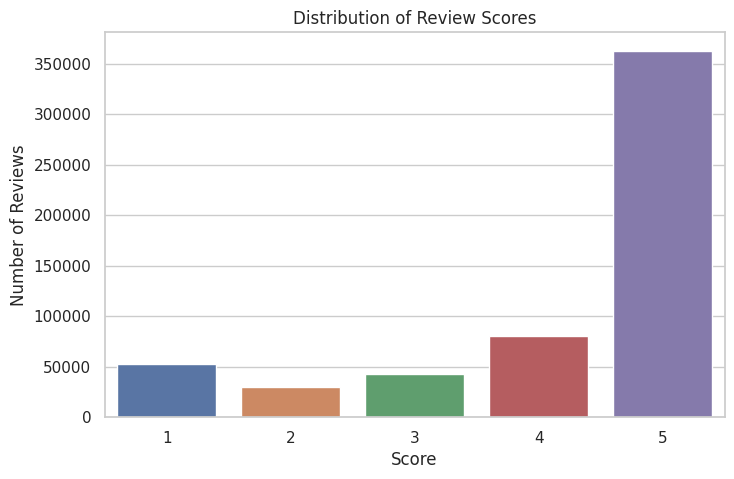

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Score")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.show()

The ratings are heavily concentrated at the upper end of the scale. This pattern matters because it suggests that users tend to review products they already like, which is typical in these online review platforms. But it also means that minimizing rating-prediction error alone may not fully capture recommendation quality. In a dataset where positive feedback dominates, the more meaningful task is often not “predict the exact number perfectly,” but rather **rank the most relevant products above less relevant ones**.

For that reason, later evaluation should include **ranking metrics** in addition to regression metrics such as RMSE or MAE.

##############

### 4.2 Reviews over time

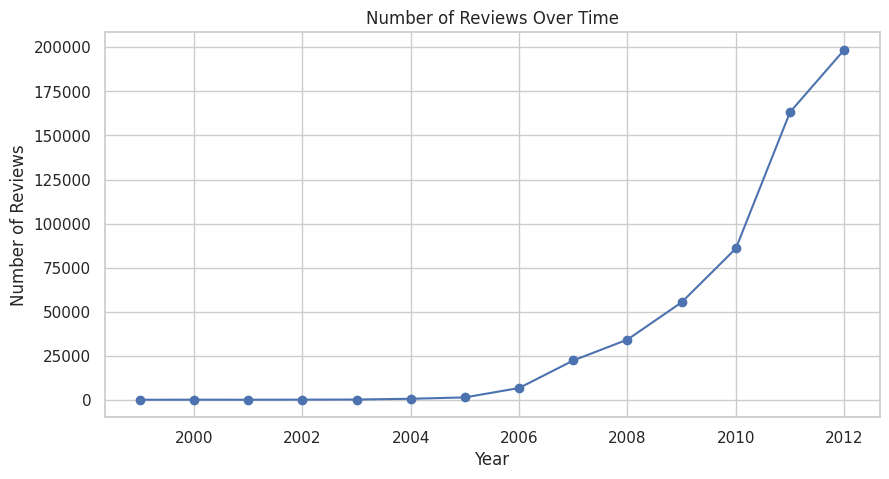

In [15]:
reviews_per_year = df["review_time"].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 5))
reviews_per_year.plot(kind="line", marker="o")
plt.title("Number of Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

Even if we do not build a fully time-aware recommender in this notebook, this plot shows that temporal effects are real and should be acknowledged when interpreting results.

It also means that random train-test splitting, while convenient, is not the only possible evaluation strategy. In a real production setting, a temporal split would often be more realistic because the model would need to recommend future items based on past interactions.

###################

### 4.3 Long-Tail structure of user and product activity


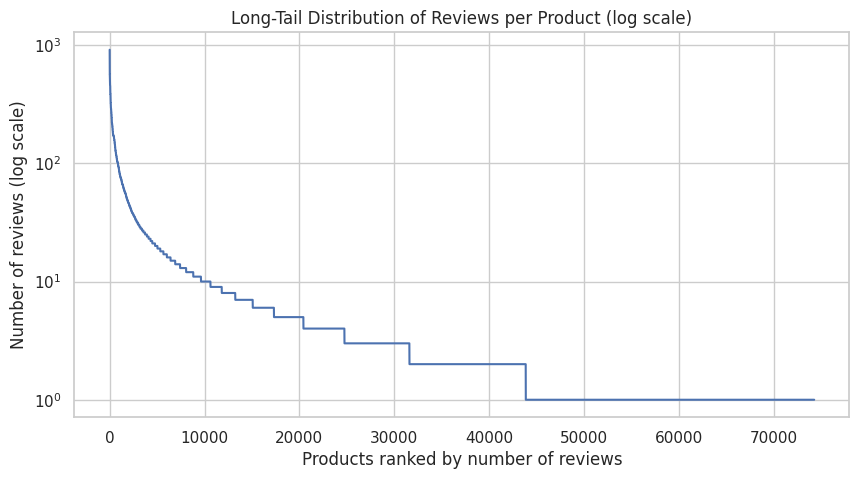

In [16]:
product_review_counts = df.groupby("ProductId").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(range(len(product_review_counts)), product_review_counts.values)
plt.yscale("log")
plt.title("Long-Tail Distribution of Reviews per Product (log scale)")
plt.xlabel("Products ranked by number of reviews")
plt.ylabel("Number of reviews (log scale)")
plt.show()

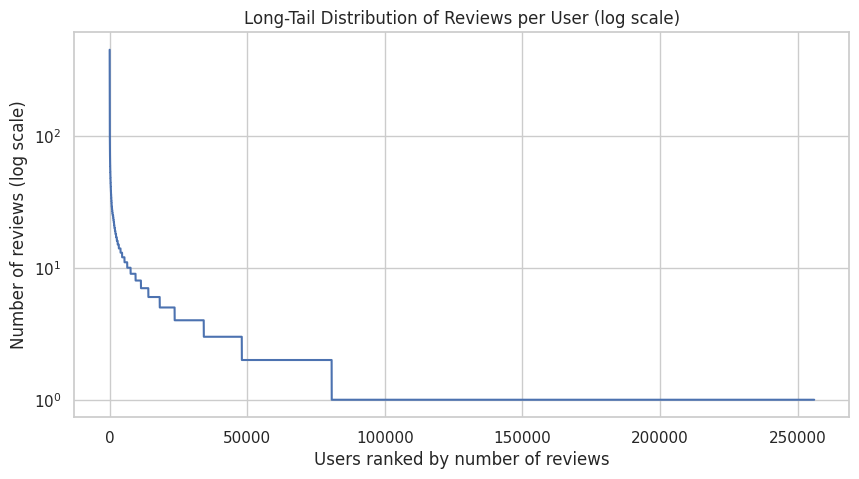

In [17]:
user_review_counts = df.groupby("UserId").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(range(len(user_review_counts)), user_review_counts.values)
plt.yscale("log")
plt.title("Long-Tail Distribution of Reviews per User (log scale)")
plt.xlabel("Users ranked by number of reviews")
plt.ylabel("Number of reviews (log scale)")
plt.show()

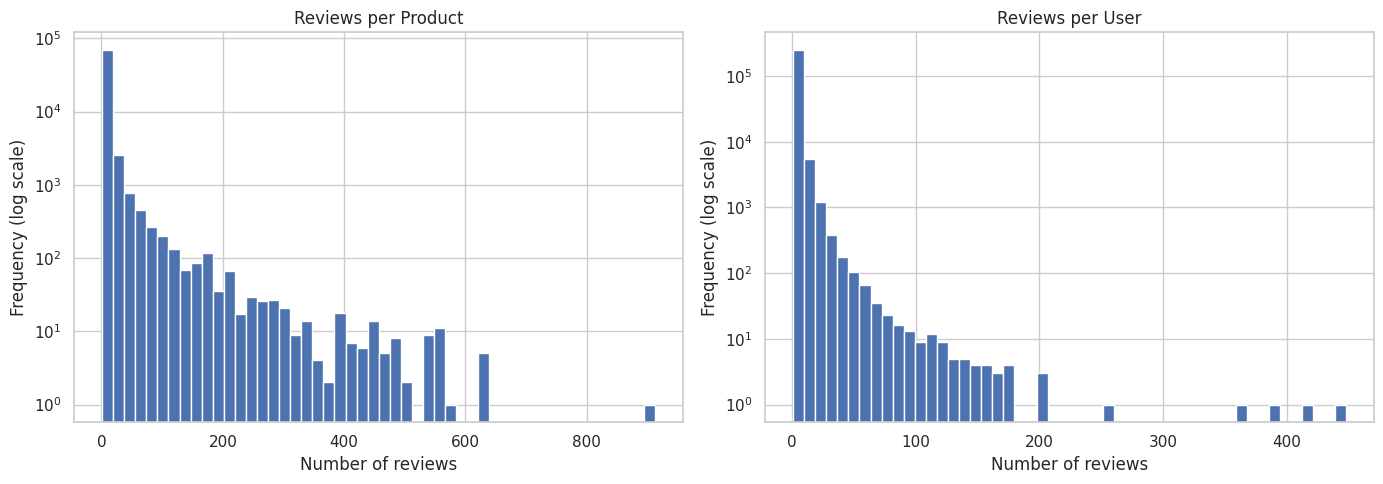

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(product_review_counts.values, bins=50, log=True)
axes[0].set_title("Reviews per Product")
axes[0].set_xlabel("Number of reviews")
axes[0].set_ylabel("Frequency (log scale)")

axes[1].hist(user_review_counts.values, bins=50, log=True)
axes[1].set_title("Reviews per User")
axes[1].set_xlabel("Number of reviews")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

Both users and products follow a pronounced long-tail distribution. On the product side, a small number of items receive a large share of reviews, while the majority attract only limited attention. On the user side, a relatively small group of highly active reviewers contributes many interactions, whereas most users leave very few reviews.

This matters because it creates an uneven recommendation environment. Popularity-based methods may perform well on frequently reviewed items simply because activity is concentrated around them, but they risk overexposing already dominant products. At the same time, collaborative filtering becomes harder for the many users and items that lie in the tail, since they provide only limited interaction history. This is a strong reason to compare different recommender families rather than relying on a single approach.


#################

### 4.4 Numerical interaction analysis and sparsity

In [19]:
interaction_summary = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Unique users",
        "Unique products",
        "Average reviews per user",
        "Average reviews per product",
        "Median reviews per user",
        "Median reviews per product"
    ],
    "Value": [
        len(df),
        df["UserId"].nunique(),
        df["ProductId"].nunique(),
        round(df.groupby("UserId").size().mean(), 2),
        round(df.groupby("ProductId").size().mean(), 2),
        int(df.groupby("UserId").size().median()),
        int(df.groupby("ProductId").size().median())
    ]
})

interaction_summary

,Metric,Value
0,Total reviews,568454.00
1,Unique users,256059.00
2,Unique products,74258.00
3,Average reviews per user,2.22
4,Average reviews per product,7.66
5,Median reviews per user,1.00
6,Median reviews per product,2.00


The numerical summary confirms that the dataset is extremely sparse despite its large size. Although it contains **568,454 reviews**, these are spread across **256,059 users** and **74,258 products**. The average number of reviews per user is only **2.22**, while the median is **1**, meaning that at least half of all users appear just once. On the product side, the average is **7.66 reviews per product**, but the median is only **2**, so most products are also weakly represented.

The histograms make this sparsity visually clear: interaction counts are heavily concentrated near very small values, with only a small minority of users and products having rich histories. This is one of the defining structural properties of the dataset. It implies that recommendation quality cannot be judged only by whether a model fits dense interaction patterns well; it must also be evaluated in terms of how robustly it handles limited information, which is the normal case here rather than the exception.


#############################

## **5. Recommendation Problem Setup**

### 5.1 Recommendation task definition

We study product recommendation using explicit user feedback in the form of review scores. We consider two related tasks:

- **Rating prediction**: estimate the score a user would give to a product.
- **Top-N recommendation**: rank products so that the most relevant items appear first.

Since the business goal is to improve product display, the ranking task is the most practically important.

### 5.2 Relevance definition

To evaluate ranked recommendations, we need a clear definition of relevance. In this notebook, an interaction is considered **relevant** if the observed review score is **4 or 5**.

This converts the explicit rating signal into a binary relevance signal for ranking evaluation.

In [1]:
relevance_threshold = 4
df_model["is_relevant"] = (df_model["Score"] >= relevance_threshold).astype(int)

print("Relevant interaction rate:", round(df_model["is_relevant"].mean(), 4))

NameError: name 'df_model' is not defined

### 5.3 Evaluation strategy

Because this is a recommender-systems project rather than a pure prediction task, evaluation must be multi-dimensional.

We will use:

- **Regression metrics** for models that predict explicit scores:
  - RMSE
  - MAE

- **Ranking metrics** for recommendation usefulness:
  - Precision@K
  - Recall@K
  - MAP@K
  - NDCG@K

- **Behavioral and catalog-oriented metrics** where appropriate:
  - coverage
  - popularity bias / concentration of recommendations
  - qualitative recommendation examples

This evaluation design is important because a model can achieve decent score prediction while still producing poor ranked recommendations, or it can recommend only the most popular products while ignoring much of the catalog.

##################################

### 5.4 Train-Test split

In [ ]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train users:", train_df["UserId"].nunique())
print("Test users:", test_df["UserId"].nunique())
print("Train products:", train_df["ProductId"].nunique())
print("Test products:", test_df["ProductId"].nunique())

## **6. Baseline Recommenders**

The random baseline recommends unseen products at random. It does not use ratings, popularity, or similarity, so it serves as a weak lower-bound benchmark.

### 6.1 Prepare data for surpise

To keep model training and evaluation consistent across baselines and collaborative filtering methods, we use the `surprise` library. It is designed for explicit-feedback recommendation tasks and provides a clean framework for rating prediction.

In [22]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_model[["UserId", "ProductId", "Score"]], reader)

trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

print("Surprise trainset size:", trainset.n_ratings)
print("Surprise testset size:", len(testset))

Surprise trainset size: 175632
Surprise testset size: 43908


### 6.2 Random recommender

In [26]:
random_model = NormalPredictor()
random_model.fit(trainset)

random_predictions = random_model.test(testset)

random_rmse = accuracy.rmse(random_predictions, verbose=False)
random_mae = accuracy.mae(random_predictions, verbose=False)

print("Random Baseline")
print(f"RMSE: {random_rmse:.4f}")
print(f"MAE:  {random_mae:.4f}")

Random Baseline
RMSE: 1.5896
MAE:  1.1904


### 6.3 Baseline bias model

`BaselineOnly` predicts ratings using user and item bias terms. It is still simple, but more informed than a random predictor because it captures tendencies such as some users rating higher on average and some products receiving higher ratings overall.

In [27]:
baseline_model = BaselineOnly()
baseline_model.fit(trainset)

baseline_predictions = baseline_model.test(testset)

baseline_rmse = accuracy.rmse(baseline_predictions, verbose=False)
baseline_mae = accuracy.mae(baseline_predictions, verbose=False)


print("Baseline Bias Model")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"MAE:  {baseline_mae:.4f}")

Estimating biases using als...
Baseline Bias Model
RMSE: 0.9883
MAE:  0.7607


### 6.4 Mean-rating recommender with minimum support

In [30]:
min_support = 20

item_stats = (
    train_df.groupby("ProductId")["Score"]
    .agg(["mean", "count"])
    .reset_index()
)

mean_rating_baseline = (
    item_stats[item_stats["count"] >= min_support]
    .sort_values(["mean", "count"], ascending=[False, False])
    .rename(columns={"mean": "avg_rating", "count": "num_reviews"})
)

mean_rating_baseline.head(10)

,ProductId,avg_rating,num_reviews
1934,B000ED9L9E,5.000000,29
12205,B0030VJ9UI,4.967742,31
3403,B000G82L62,4.916667,24
9969,B001PICX42,4.909091,22
12206,B0030VJA7K,4.884615,26
15948,B006ACQY66,4.878788,33
12196,B0030VBSBG,4.862069,29
2403,B000EVG8HY,4.854701,117
3014,B000FFVYF0,4.850000,20
6023,B000WFS9G0,4.835443,79


This baseline highlights products that are not only highly rated, but also supported by a reasonable number of reviews. It is more reliable than ranking by average score alone.


### 6.5 Baseline comparison

In [28]:
baseline_results = pd.DataFrame({
    "Model": ["Random Baseline", "Baseline Bias Model"],
    "RMSE": [random_rmse, baseline_rmse],
    "MAE": [random_mae, baseline_mae]
})

baseline_results.sort_values("RMSE")

,Model,RMSE,MAE
1,Baseline Bias Model,0.988250,0.760656
0,Random Baseline,1.589607,1.190392


In [31]:
mean_rating_baseline.head(10)

,ProductId,avg_rating,num_reviews
1934,B000ED9L9E,5.000000,29
12205,B0030VJ9UI,4.967742,31
3403,B000G82L62,4.916667,24
9969,B001PICX42,4.909091,22
12206,B0030VJA7K,4.884615,26
15948,B006ACQY66,4.878788,33
12196,B0030VBSBG,4.862069,29
2403,B000EVG8HY,4.854701,117
3014,B000FFVYF0,4.850000,20
6023,B000WFS9G0,4.835443,79


The results already show a large improvement from a random predictor to a simple bias-based model. This is useful because it establishes that even very basic structure in the data carries predictive value. The mean-rating baseline, meanwhile, provides a strong non-personalized ranking reference that we can later compare against more personalized methods.


##############

## **7. Collaborative Filtering**

### 7.1 User based collaborative filtering

User-based collaborative filtering predicts a user’s rating from the ratings of similar users.

In [ ]:
sim_options_user = {
    "name": "pearson",
    "user_based": True
}

user_cf = KNNWithMeans(sim_options=sim_options_user)
user_cf.fit(trainset)

user_cf_predictions = user_cf.test(testset)

user_cf_rmse = accuracy.rmse(user_cf_predictions, verbose=False)
user_cf_mae = accuracy.mae(user_cf_predictions, verbose=False)

print("User-Based Collaborative Filtering")
print(f"RMSE: {user_cf_rmse:.4f}")
print(f"MAE:  {user_cf_mae:.4f}")

### 7.2 Item based collaborative filtering

Item-based collaborative filtering predicts preferences from relationships between products rather than between users.

In [ ]:
sim_options_item = {
    "name": "pearson",
    "user_based": False
}

item_cf = KNNWithMeans(sim_options=sim_options_item)
item_cf.fit(trainset)

item_cf_predictions = item_cf.test(testset)

item_cf_rmse = accuracy.rmse(item_cf_predictions, verbose=False)
item_cf_mae = accuracy.mae(item_cf_predictions, verbose=False)

print("Item-Based Collaborative Filtering")
print(f"RMSE: {item_cf_rmse:.4f}")
print(f"MAE:  {item_cf_mae:.4f}")

### 7.3 Model based collaborative filtering (SVD / Matrix factorization)

Model-based collaborative filtering learns latent user and item factors from the rating matrix. Here, we use SVD as the main model-based approach.

In [ ]:
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

svd_predictions = svd_model.test(testset)

svd_rmse = accuracy.rmse(svd_predictions, verbose=False)
svd_mae = accuracy.mae(svd_predictions, verbose=False)

print("SVD")
print(f"RMSE: {svd_rmse:.4f}")
print(f"MAE:  {svd_mae:.4f}")

### 7.4 Collaborative filtering comparison

In [ ]:
cf_results = pd.DataFrame({
    "Model": [
        "User-Based CF",
        "Item-Based CF",
        "SVD"
    ],
    "RMSE": [
        user_cf_rmse,
        item_cf_rmse,
        svd_rmse
    ],
    "MAE": [
        user_cf_mae,
        item_cf_mae,
        svd_mae
    ]
})

cf_results.sort_values("RMSE")

## **8. Content Based Recommendations**

### 8.1 Text representation

### 8.2 Product profile construction

### 8.3 Content based recommendation generation

### 8.4 Content based evaluation

## **9. Hybrid Recommendations**

### 9.1 Hybrid design

### 9.2 Score combination strategy

### 9.3 Hybrid evaluation